In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pyprojroot import here
import sys
sys.path.append(str(here("Scripts")))
from data_utils import best_players_plots, table_simulation, expected_stats_vs_actuals

In [2]:
data_path = here("Data/FPL_data_tidy.parquet")
data = pd.read_parquet(data_path)

In [3]:
data.head()

,team_name,first_name,match_id,web_name,position,second_name,status,tackles_won_percent,xg,ground_duels_won,transfers_out_event,shots_on_target,now_cost,accurate_passes,now_cost_rank,headed_clearances,bonus,gk_accurate_long_balls,touches_opposition_box,saves,event_points,final_third_passes,accurate_crosses,team_goals_conceded,big_chances_missed,high_claim,cost_change_start,minutes_played,interceptions,aerial_duels_won,gk_accurate_passes,expected_goal_involvements,tackles_won,xgot_faced,touches,player_code,penalties_order,sweeper_actions,influence,ground_duels_won_percent,team_code,value_season,total_points,tackles,transfers_out,transfers_in,expected_assists,accurate_passes_percent,ep_next,fouls_committed,clearances,total_shots,selected_rank,recoveries,goals_conceded,duels_won,goals_prevented,transfers_in_event,ep_this,xa,finish_min,penalties_missed,xgot,id,duels_lost,chance_of_playing_next_round,ict_index,offsides,form,threat,cost_change_event,assists,chances_created,gw,selected_by_percent,direct_freekicks_order,successful_dribbles_percent,chance_of_playing_this_round,penalties_scored,accurate_long_balls,start_min,dreamteam_count,corners_and_indirect_freekicks_order,team_strength,successful_dribbles,creativity,was_fouled,bps,blocks,expected_goals_conceded,aerial_duels_won_percent,expected_goals,value_form,accurate_crosses_percent,dribbled_past,goals,accurate_long_balls_percent,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
0,Brighton,James,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,MID,Milner,a,50,0.0,4,421,0,5.0,28,172,0,0,0,2,0,2,2,2,0,0,0,0,82,0,0,0,0.11,2,0.0,48,15157,6,0,22.4,80,36,0.4,2,4,421,513,0.11,85,1.6,1,0,0,471,0,0,4,0.0,513,1.6,0.11,82,0,0.0,134,2,0,7.0,0,2.0,4,0,0,3,1,0.1,7,0,0,0,1,0,0,1,3,0,43.8,0,10,2,0.45,0,0.0,0.4,29,0,0,33,2425,0.0,0.120732,0.120732,0.493902
1,Brighton,James,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,MID,Milner,a,0,0.16,3,635,1,5.0,22,177,0,0,0,2,0,2,6,1,1,0,0,0,73,1,0,0,0.31,0,0.0,42,15157,6,0,28.6,75,36,0.8,4,1,1548,2267,0.15,73,1.0,1,2,2,448,2,0,3,0.0,1189,2.0,0.04,73,0,0.0,134,1,0,10.7,0,2.0,12,0,0,1,2,0.1,7,100,0,0,0,0,0,1,3,1,66.2,1,22,0,1.77,0,0.16,0.4,100,0,0,0,2425,0.19726,0.049315,0.382192,2.182192
2,Brighton,James,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,MID,Milner,d,0,0.0,0,1998,0,5.0,2,185,0,0,0,0,0,1,0,0,0,0,0,0,17,1,0,0,0.31,0,0.0,4,15157,6,0,28.6,0,36,1.0,5,0,4535,4199,0.15,100,1.7,1,0,0,461,0,0,0,0.0,472,0.7,0.0,17,0,0.0,134,1,75,10.7,0,1.7,12,0,0,0,3,0.1,7,0,0,0,0,0,0,1,3,0,66.3,0,24,0,1.98,0,0.16,0.3,0,0,0,0,2425,0.0,0.0,1.641176,10.482353
3,Brighton,James,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,MID,Milner,a,0,0.0,0,0,0,5.0,0,192,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0.31,0,0.0,1,15157,6,0,28.6,0,36,1.2,6,0,10991,5014,0.15,0,0.0,0,0,0,586,0,0,0,0.0,0,0.0,0.0,93,0,0.0,134,0,100,10.7,0,0.2,12,0,0,0,38,0.0,7,0,0,0,0,93,0,8,3,0,66.3,0,27,0,1.98,0,0.16,0.0,0,0,0,0,2425,0.0,0.0,27.9,178.2
4,Brighton,James,25-26-prem-brighton-hove-albion-vs-fulham,Milner,MID,Milner,a,0,0.0,0,497,0,4.9,1,283,0,0,0,0,0,1,0,0,1,0,0,-1,2,0,0,0,0.0,0,0.0,1,15157,1,0,0.0,0,36,3.1,1,0,20304,14413,0.0,0,-0.5,0,0,0,467,0,0,0,0.0,113,0.0,0.0,90,0,0.0,170,0,100,0.0,0,0.0,0,0,0,0,1,0.1,7,0,0,0,0,0,0,5,3,0,0.1,0,3,0,0.24,0,0.0,0.0,0,0,0,0,2526,0.0,0.0,0.0,10.8


In [4]:
data.describe()

,tackles_won_percent,xg,ground_duels_won,transfers_out_event,shots_on_target,now_cost,accurate_passes,now_cost_rank,headed_clearances,bonus,gk_accurate_long_balls,touches_opposition_box,saves,event_points,final_third_passes,accurate_crosses,team_goals_conceded,big_chances_missed,high_claim,cost_change_start,minutes_played,interceptions,aerial_duels_won,gk_accurate_passes,expected_goal_involvements,tackles_won,xgot_faced,touches,player_code,penalties_order,sweeper_actions,influence,ground_duels_won_percent,team_code,value_season,total_points,tackles,transfers_out,transfers_in,expected_assists,accurate_passes_percent,ep_next,fouls_committed,clearances,total_shots,selected_rank,recoveries,goals_conceded,duels_won,goals_prevented,transfers_in_event,ep_this,xa,finish_min,penalties_missed,xgot,id,duels_lost,chance_of_playing_next_round,ict_index,offsides,form,threat,cost_change_event,assists,chances_created,gw,selected_by_percent,direct_freekicks_order,successful_dribbles_percent,chance_of_playing_this_round,penalties_scored,accurate_long_balls,start_min,dreamteam_count,corners_and_indirect_freekicks_order,team_strength,successful_dribbles,creativity,was_fouled,bps,blocks,expected_goals_conceded,aerial_duels_won_percent,expected_goals,value_form,accurate_crosses_percent,dribbled_past,goals,accurate_long_balls_percent,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
count,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.0,21629.000000,21629.0,21629.0,21629.0,21629.0
mean,17.958713,0.09547,2.266633,18788.944057,0.293356,5.355893,24.298303,267.181885,0.814323,1.878127,0.354709,1.714457,0.186971,2.766009,3.46507,0.276203,1.128207,0.100097,0.052568,-0.765592,64.11688,0.520782,0.926441,1.412271,1.400731,0.390957,0.08944,41.381016,302427.731472,5.589902,0.037912,128.849295,24.158121,28.505201,6.769851,23.363586,1.092006,335522.10939,366081.342179,0.550324,43.590688,2.46789,0.710712,1.576356,0.837487,248.638263,3.091914,0.090573,3.193074,0.001965,22819.811827,2.514684,0.062481,78.728466,0.001572,0.095013,350.86139,3.185584,52.085163,29.962846,0.006242,2.518341,81.429146,-0.008785,0.066901,0.625826,16.600767,4.184863,6.437145,12.518424,52.036618,0.006704,1.345046,11.973092,0.311018,7.183689,3.22026,0.478154,89.587614,0.686856,99.239401,0.231264,8.743726,17.477553,0.850499,0.465814,5.585279,0.471219,0.093532,18.246937,2471.986083,0.194264,0.114128,3.902294,24.725067
std,35.098366,0.209432,2.213073,57243.525544,0.62193,1.279057,20.109014,191.81906,1.430408,4.214434,1.611331,2.283561,0.857734,2.996783,3.649416,0.69217,1.135402,0.345938,0.323201,2.130754,32.223885,0.862251,1.398928,5.747286,2.734579,0.837778,0.416617,26.325296,163536.324841,1.229538,0.255593,187.427276,32.365883,27.643208,5.696585,33.698016,1.391587,850318.265747,950336.437679,1.049158,41.704023,2.066963,0.956298,2.227503,1.210921,187.139706,2.73281,0.458141,2.720519,0.194973,69027.562698,2.075067,0.118904,28.779613,0.040768,0.260246,207.616282,2.776082,49.510251,45.500263,0.094258,1.92088,161.275192,0.327683,0.265468,1.00592,10.031105,8.445312,1.570308,29.674273,49.365559,0.087086,2.030696,27.334515,0.852514,2.002347,0.765164,0.916349,156.255212,0.97367,138.407323,0.566594,11.897167,33.159483,1.948666,0.339432,18.960295,0.802983,0.323669,32.090364,50.378763,1.223325,0.585832,1

In [5]:
data.shape

(21629, 102)

Text(0, 0.5, 'Liczba graczy')

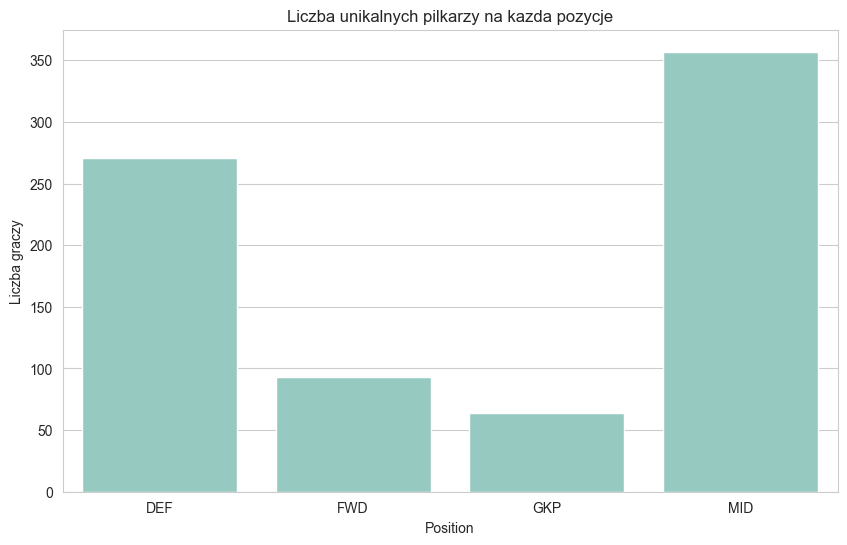

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(data.groupby("position")["web_name"].nunique())
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [7]:
[c for c in data.columns if "points" in c]

['event_points', 'total_points']

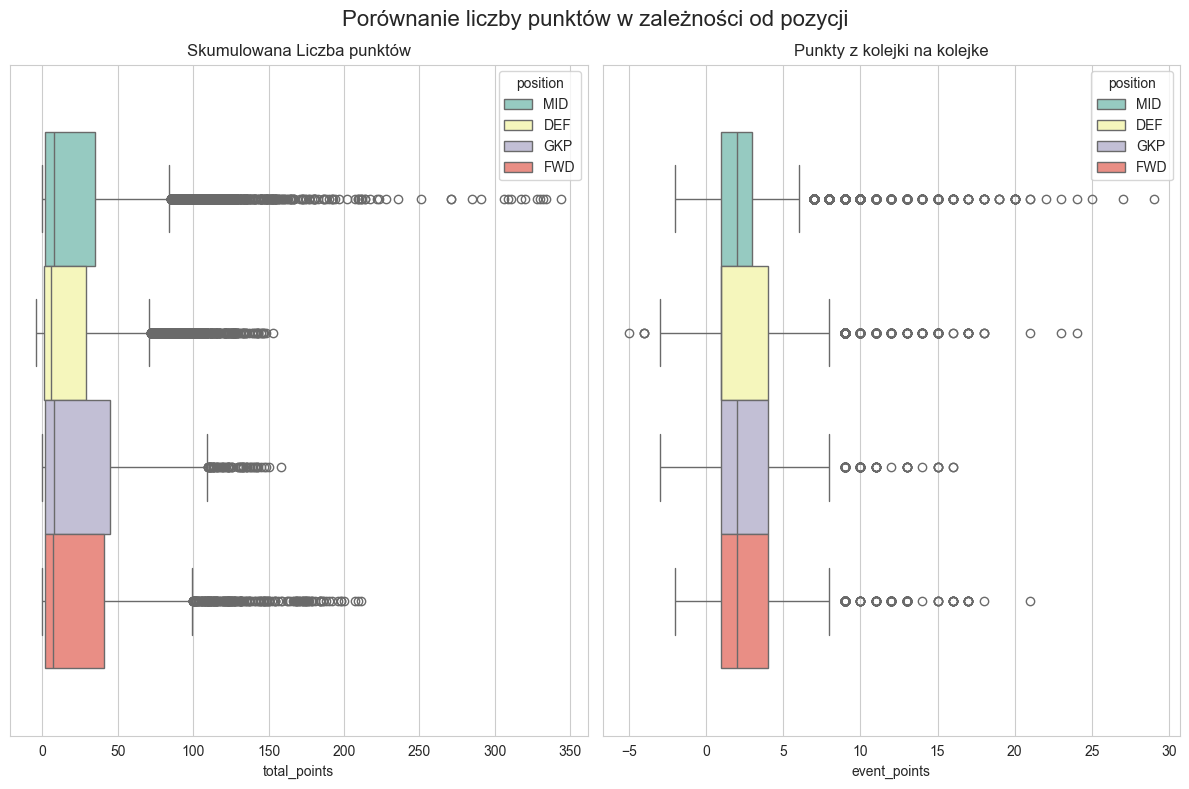

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

sns.boxplot(data=data, x="total_points", hue="position", ax=ax[0])
sns.boxplot(data=data, x="event_points", hue="position", ax=ax[1])

ax[0].set_title("Skumulowana Liczba punktów")
ax[1].set_title("Punkty z kolejki na kolejke")
fig.suptitle("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Text(0.5, 1.0, 'Rozkład Total Points')

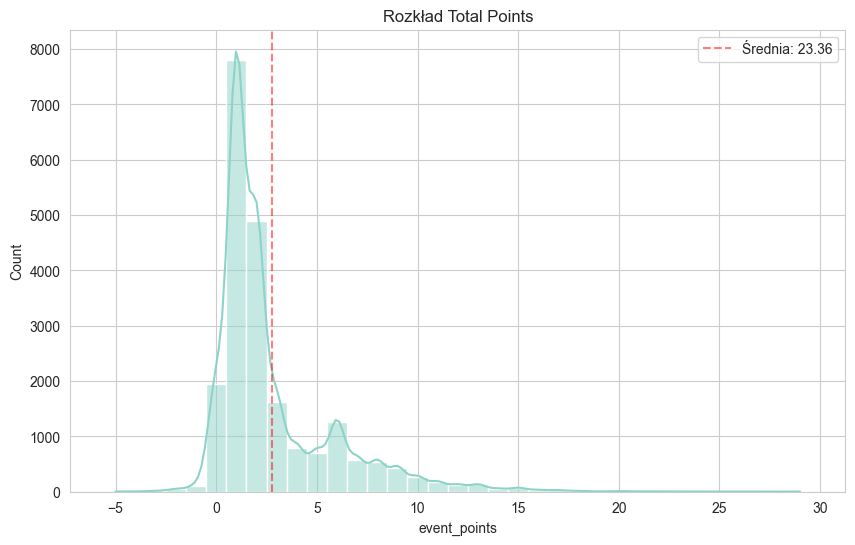

In [9]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.event_points,
             kde=True,
             discrete=True,
             bins=30)
ax.axvline(data.event_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.total_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Total Points")

<Axes: >

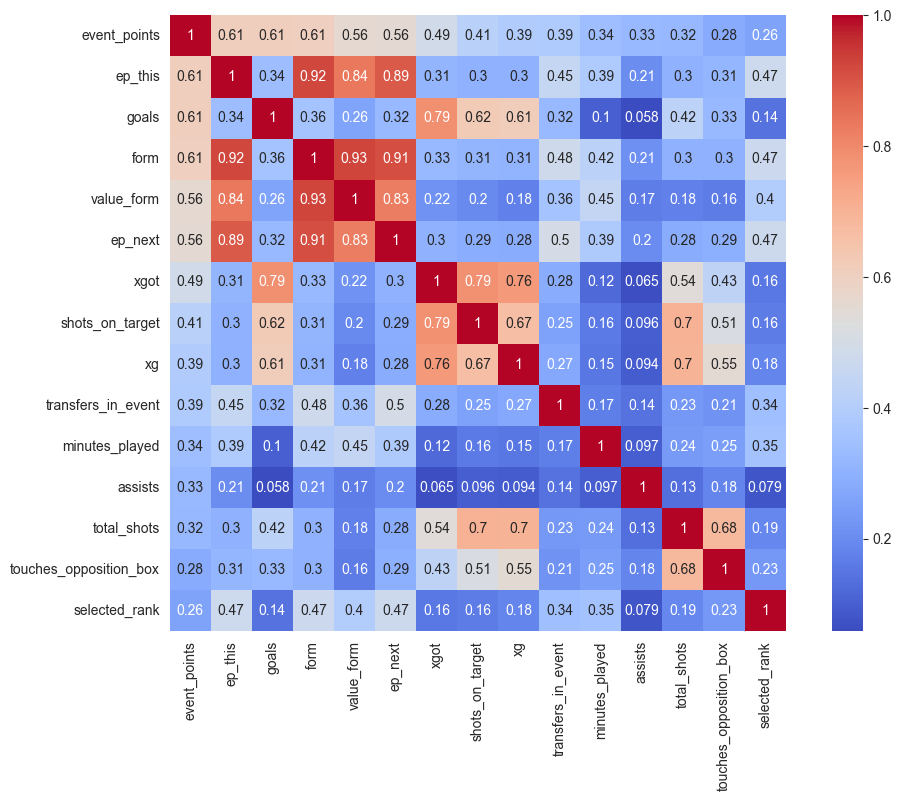

In [10]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["event_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

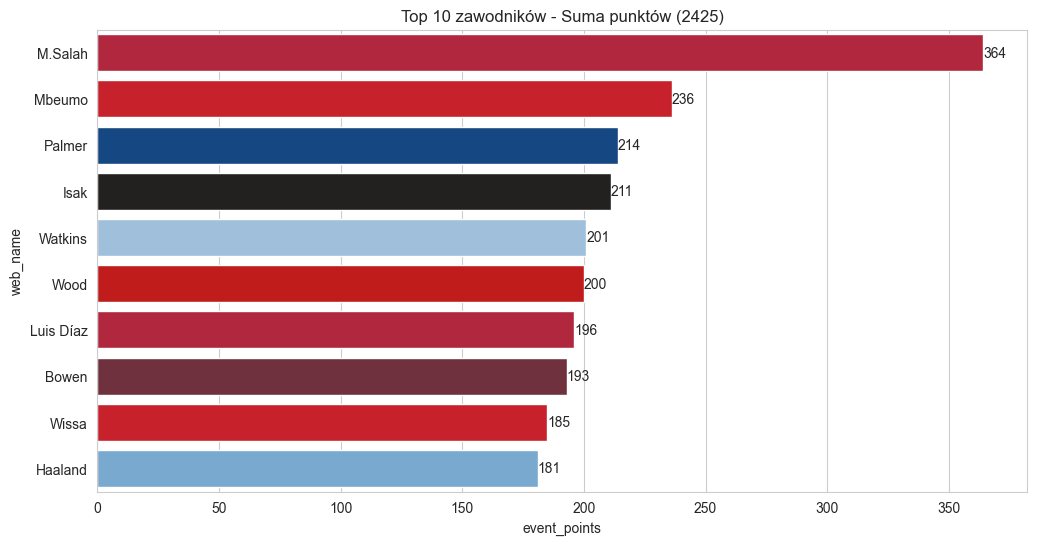

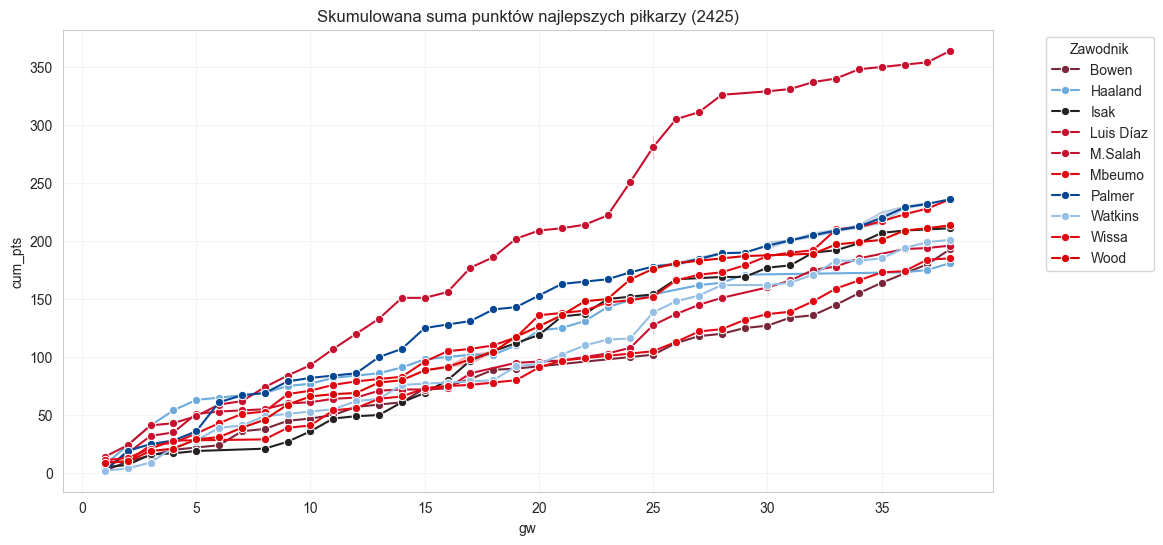

In [13]:
best_players_plots(df=data,
                   num_players=10,
                   season=2425)

In [14]:
data["value_ratio"] = (data.event_points / data.now_cost).fillna(0)


In [17]:
data[["web_name", "value_ratio", "position", "gw", "season_id"]].sort_values(by="value_ratio", ascending=False).head()

,web_name,value_ratio,position,gw,season_id
17994,Van de Ven,4.893617,DEF,9,2526
6849,Barnes,4.576271,MID,32,2425
19438,Schade,4.509804,MID,13,2425
12923,Lewis-Potter,4.375,DEF,17,2526
14730,J.Timber,4.363636,DEF,2,2526


In [19]:
x_cols = [c for c in data.columns if "expected" in c]

In [20]:
x_cols

['expected_goal_involvements',
 'expected_assists',
 'expected_goals_conceded',
 'expected_goals',
 'expected_goal_involvements_per_90',
 'expected_goals_conceded_per_90']

In [ ]:
data.was_home.unique()

In [23]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="total_points",
    hue="was_home",
    estimator="mean",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

ValueError: Could not interpret value `was_home` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [24]:
teams_avenue_form = data[data.season_id=="2025-26"].groupby(["team", "was_home"])["total_points"].mean().reset_index()
teams_avenue_form = teams_avenue_form.pivot(index="team", columns="was_home", values="total_points")
teams_avenue_form["home_advantage"] = teams_avenue_form[True] - teams_avenue_form[False]
teams_avenue_form.sort_values(by="home_advantage", ascending=False, inplace=True)


KeyError: 'team'

In [ ]:
teams_avenue_form.head()

In [ ]:
teams_avenue_form.tail()

In [ ]:
plt.figure(figsize=(10, 8))
ax =sns.barplot(data=pd.concat([teams_avenue_form.head(), teams_avenue_form.tail()], axis=0),
            x="home_advantage",
            hue="team",
            y="team",
            palette=team_colors,
            errorbar=None)
plt.title("Największa / Najmniejsza przewaga własnego boiska w obecnym sezonie", fontsize=14)
plt.xlabel("Różnica punktów (Dom - Wyjazd)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")


In [ ]:
team_names = [team for team in data[data.season_id=="2025-26"].team.unique()]
team_names

In [ ]:
data[data.season_id=="2025-26"].gw.unique()

In [27]:
teams = table_simulation(df=data,
                         season="2025-26")

KeyError: 'was_home'

In [ ]:
teams.shape

In [ ]:
teams

In [ ]:
plt.figure(figsize=(12,8))
ax = sns.scatterplot(data=teams,
            hue="team",
            x="points",
            y="team",
            palette=team_colors,
            s=400,
            alpha=0.6,
            legend=False,
            edgecolor='black')
plt.title(f"Ilosc punktow zespolow PL w sezonie 2025-26 do kolejki {data[data.season_id=='2025-26'].gw.max()}")
plt.ylabel("")
plt.xlabel("Ilosc punktow")
for y, x in zip(teams['team'], teams['points']):
    ax.text(x, y, x,
            fontsize=15,
            ha='center',
            va='center',
            fontweight='bold',
           )
plt.grid(axis='x', alpha=0.1, linestyle='--')

In [26]:
expected_stats_vs_actuals(df=data,
                          teams=teams,
                          season="2025-26",
                          position="FWD",
                          expected_stat="xg",
                          actual_stat="goals")

NameError: name 'teams' is not defined

In [ ]:
expected_stats_vs_actuals(df=data,
                          teams=teams,
                          season="2025-26",
                          position="GK",
                          expected_stat="expected_goals_conceded",
                          actual_stat="goals_conceded")